# Proyecto final

## Desarrollo de una herramienta analítica usando paquetes especializados para análisis de datos en Python

Para el desarrollo de este proyecto puedes utilizar cualquier librería externa. Te recomendamos leer por completo el enunciado antes de comenzar, de forma que tengas claro el propósito global de la actividad y puedas desarrollar tu solución apuntando a él desde el inicio.

Al desarrollar este proyecto pondrás a prueba tus habilidades para:

1. Identificar y abordar preguntas de negocio y de *analytics*.
2. Leer datos desde archivos y almacenarlos utilizando métodos de librerías especializadas.
3. Explorar, modificar, limpiar y unir objetos tablas de datos.
4. Implementar análisis combinando métricas descriptivas, visualización, filtrado y agrupación.
5. Implementar análisis basado en modelos estadísticos o de *machine learning*.

##  Contexto: desigualdad y factores de éxito en pruebas Saber 11 en Colombia

El ICFES es el Instituto Colombiano para el Fomento de la Educación Superior y está adscrito al Ministerio de Educación a nivel nacional. Como parte de sus funciones, el ICFES administra las pruebas Saber 11, las cuales evalúan a todos los estudiantes del país al final de su educación secundaria. El examen contiene preguntas que evalúan una variedad de áreas del conocimiento (ej., matemáticas, física, inglés, etc.) y se lleva a cabo dos veces al año, ajustándose a los diferentes calendarios académicos que siguen las instituciones educativas. Al momento de inscribirse a las pruebas, los estudiantes diligencian un formulario que recoge información sociodemográfica y relacionada con la institución a la que pertenecen. El fin es obtener información con respecto al desempeño de los estudiantes en la prueba y de sus características.

Al igual que otros países de la región, Colombia tiene grandes retos en términos de desigualdad, particularmente en el contexto de educación primaria y secundaria. Por esta razón, para el Estado colombiano es muy valioso el amplio registro de datos que el ICFES genera alrededor de las pruebas Saber 11, pues con ellos se pueden generar análisis sobre la calidad de la educación en el país y eventualmente dar lugar a recomendaciones sobre políticas públicas. En particular, la problemática a abordar en este caso de estudio es la desigualdad y factores de éxito en las pruebas Saber 11. 

Los objetivos de este caso de estudio son:

* Entender el contenido de los archivos de datos proporcionados sobre las pruebas Saber 11, generar un reporte acerca de sus características principales y seleccionar las partes de dicho contenido que podrían ser relevantes para el análisis.


* Identificar características de las variables de interés y relaciones entre ellas, por ejemplo, a través de agrupación, visualizaciones y estadísticas descriptivas.


* Proponer un modelo que busque relacionar las variables de interés con el desempeño de los estudiantes y concluir acerca de los posibles hallazgos que se podrían reportar para el *stakeholder*.


* Generar una herramienta que permita a un usuario interactuar con alguno de los parámetros del análisis realizado de forma relevante en el contexto del problema.

## Fase 1: obtener e inspeccionar archivos

En esta fase te harás una idea general del contenido de los datos y generarás un reporte al respecto (ej., imprimiendo mensajes, presentando tablas de resumen, etc.). Además, seleccionarás un segmento de los datos que consideres útil para realizar tu análisis.

Pautas generales:

* Utilizar una librería especializada para leer los archivos de datos y agregarlos según sea necesario (ej., utilizando los métodos `append` o `concat` si eliges cargarlos utilizando la librería `pandas`).
* Inspeccionar el archivo a partir de sus encabezados, columnas y descripciones de las variables según su tipo (ej., numéricas, categóricas).
* Declarar una estructura de datos (ej., una lista) para almacenar un subconjunto de variables que puedan ser relevantes para la problemática de interés.

Preguntas guía:

* ¿Qué dimensiones tienen los datos?
* ¿Con cuántos años y periodos de evaluación se cuenta?
* ¿Cuáles variables pueden ser de interés para la problemática planteada?
* ¿Qué porcentaje de datos faltantes o no válidos hay en las columnas de interés? ¿Qué planteas para manejarlos?

In [1]:
#https://www.datos.gov.co/Educaci-n/Resultados-nicos-Saber-11/kgxf-xxbe/about_data

In [2]:
# Implementa tu respuesta en esta celda
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
datos_raw = pd.read_csv("Archivos/Resultados_únicos_Saber_11_20260710.csv") # El archivo corresponde a los periodos 2021 y 2022
datos_raw.shape # El archivo cuenta con 1.101.465 registros y 51 columnas

(1101465, 51)

In [3]:
datos_raw['PERIODO'].unique() #Los datos son de los periodos 20211, 20221 y 20224

array([20224, 20211, 20221])

## Variables:

Las variables sociodemográficas que consideré más relevantes son: 
COLE_BILINGUE, COLE_CALENDARIO, COLE_CARACTER,  COLE_GENERO,  COLE_JORNADA, COLE_NATURALEZA, ESTU_GENERO, FAMI_ESTRATOVIVIENDA, FAMI_EDUCACIONMADRE, FAMI_EDUCACIONPADRE, FAMI_TIENEINTERNET, COLE_COD_DEPTO_UBICACION.


In [4]:
datos_raw['COLE_BILINGUE'].isnull().mean()*100  # 199.588 vacíos (18,12%), Imputar datos con un 'N' para aquellos que no son bilingues
datos_raw['COLE_CALENDARIO'].isnull().mean()*100 # 2 (0,0001%) Imputar datos con 'Otro' para aquellos que no son A o B
datos_raw['COLE_CARACTER'].isnull().mean()*100  # 44.165 vacios (4%) Imputar datos con 'Otro' para aquellos que no son A o B
datos_raw['COLE_GENERO'].isnull().mean()*100 # 2 (0,0001%)Imputar datos con 'Mixto' para aquellos que no son A o B
datos_raw['COLE_JORNADA'].isnull().mean()*100 # 2 (0,0001%) Remplazar con la moda
datos_raw['COLE_NATURALEZA'].isnull().mean()*100 # 2 (0,0001%) Remplazar con la moda
datos_raw['ESTU_GENERO'].isnull().mean()*100 # 15 vacios (0,001%), quizas pueda eliminar los registros porque es dificil imputar este dato
datos_raw['FAMI_ESTRATOVIVIENDA'].isnull().mean()*100 # 73647 vacios (6,68%), quizas pueda eliminar los registros porque es dificil imputar este dato
datos_raw['FAMI_EDUCACIONMADRE'].isnull().mean()*100 # 63.675 (5,78%) vacios, quizas pueda eliminar los registros porque es dificil imputar este dato
datos_raw['FAMI_EDUCACIONPADRE'].isnull().mean()*100 # 63.446 (5,76%) vacios, quizas pueda eliminar los registros porque es dificil imputar este dato
datos_raw['FAMI_TIENEINTERNET'].isnull().mean()*100 # 64.959 (5,89%) vacios, quizas pueda eliminar los registros porque es dificil imputar este dato
datos_raw['COLE_COD_DEPTO_UBICACION'].isnull().mean() * 100 # 2 (0,0001%) vacios, quizas pueda eliminar los registros porque es dificil imputar este dato

np.float64(0.00018157635512703536)

## Fase 2: identificar características y relaciones en las variables

En esta fase realizarás análisis descriptivo para identificar posibles patrones o relaciones entre las variables de interés para la problemática planteada. Además, expondrás estadísticas descriptivas y visualizaciones para concluir al respecto de los patrones y las relaciones identificadas. Finalmente, elegirás el segmento de los datos sobre el cual profundizarás con tu análisis (este puede ser, o no, igual al seleccionado anteriormente).

Pautas generales:

* Calcular estadísticas descriptivas básicas (por lo menos, media/mediana y varianza/desviación) para cada variable sociodemográfica relevante en el contexto del problema.
* Utilizar librerías especializadas (ej., `matplotlib`, `seaborn`, etc.) para inspeccionar visualmente variables de interés. Los métodos `distplot`, `pairplot`, `boxplot`, o `violinplot`, entre otros, pueden ser útiles.
* Utilizar el método `groupby` de `pandas`, en conjunto con métodos de visualización, puede proveer evidencia del impacto de las variables sociodemográficas de interés sobre el desempeño de los estudiantes en la prueba.

Preguntas guía:

* ¿Hay patrones de interés en las distribuciones de las variables o en las relaciones entre ellas?
* ¿Consideras que existe algún impacto significativo de variables sociodemográficas en los puntajes globales o por área?
* ¿Sobre cuáles variables harías un análisis más profundo?

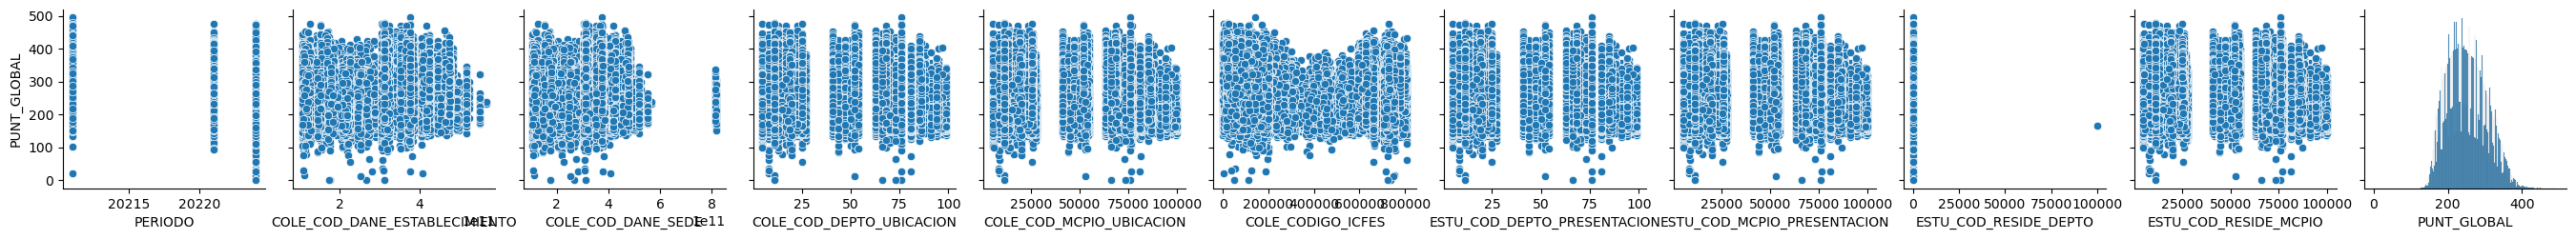

In [5]:
columnas_excluir = ['DESEMP_INGLES','PUNT_INGLES', 'PUNT_MATEMATICAS', 'PUNT_SOCIALES_CIUDADANAS',
                     'PUNT_C_NATURALES', 'PUNT_LECTURA_CRITICA']
datos = datos_raw.drop(columns=columnas_excluir)
#datos['COLE_COD_DEPTO_UBICACION'].describe()
#datos.isna().sum().sort_values(ascending=False)
sns.pairplot(datos, y_vars = ['PUNT_GLOBAL']) #Reviso el comportamiento de las principales variables numericas vs la puntuación global

<Axes: ylabel='DEPTO'>

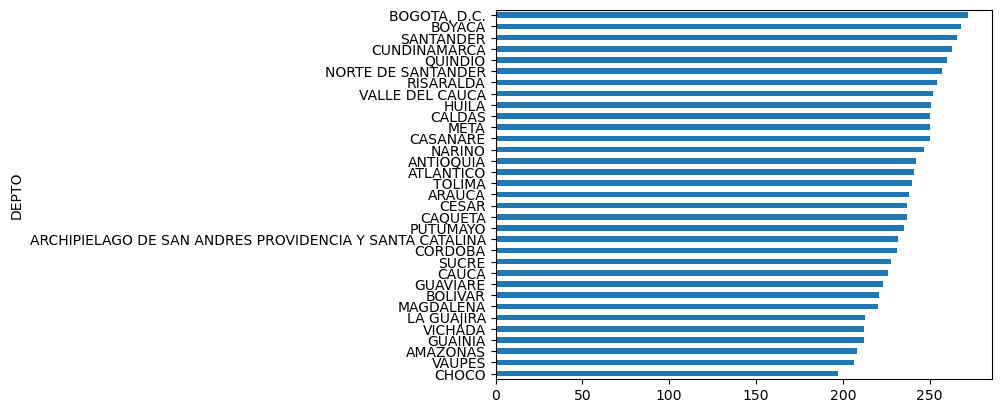

In [6]:
DEPTO = {5 : 'ANTIOQUIA',8 : 'ATLANTICO',11 : 'BOGOTA, D.C.',13 : 'BOLIVAR',15 : 'BOYACA',17 : 'CALDAS',18 : 'CAQUETA',
         19 : 'CAUCA',20 : 'CESAR',23 : 'CORDOBA',25 : 'CUNDINAMARCA',27 : 'CHOCO',41 : 'HUILA',44 : 'LA GUAJIRA',
         47 : 'MAGDALENA',50 : 'META',52 : 'NARIÑO',54 : 'NORTE DE SANTANDER',63 : 'QUINDIO',66 : 'RISARALDA',68 : 'SANTANDER'
         ,70 : 'SUCRE',73 : 'TOLIMA',76 : 'VALLE DEL CAUCA',81 : 'ARAUCA',85 : 'CASANARE',86 : 'PUTUMAYO',
         88 : 'ARCHIPIELAGO DE SAN ANDRES PROVIDENCIA Y SANTA CATALINA',91 : 'AMAZONAS',94 : 'GUAINIA',95 : 'GUAVIARE',
         97 : 'VAUPES',99 : 'VICHADA'}

datos ['DEPTO'] = datos['COLE_COD_DEPTO_UBICACION'].map(DEPTO)
medidas = ['mean','median','std']

datos.groupby ('DEPTO')['PUNT_GLOBAL'].median().sort_values().plot(kind='barh')


In [7]:
medidas = ['mean','median','std','min','max','count']
columnas = ['COLE_BILINGUE','COLE_CALENDARIO','COLE_CARACTER', 
            'COLE_GENERO', 'COLE_JORNADA','COLE_NATURALEZA','ESTU_GENERO',
            'FAMI_ESTRATOVIVIENDA','FAMI_EDUCACIONMADRE','FAMI_EDUCACIONPADRE','FAMI_TIENEINTERNET',
            'DEPTO']

#datos.groupby(columnas[0])['PUNT_GLOBAL'].agg(medidas) ##Colegio bilingue es representativo
#datos.groupby(columnas[1])['PUNT_GLOBAL'].agg(medidas) ##Calendario B es representativo
#datos.groupby(columnas[2])['PUNT_GLOBAL'].agg(medidas) #Colegio académico tiene mejor puntaje
#datos.groupby(columnas[3])['PUNT_GLOBAL'].agg(medidas) #Colegio masculino tiene mejor puntaje
#datos.groupby(columnas[4])['PUNT_GLOBAL'].agg(medidas) ##Jornada completa tiene mejor puntaje
#datos.groupby(columnas[5])['PUNT_GLOBAL'].agg(medidas) ##No oficial tiene mejor puntaje
#datos.groupby(columnas[6])['PUNT_GLOBAL'].agg(medidas) #Masculino tiene mejor puntaje
#datos.groupby(columnas[7])['PUNT_GLOBAL'].agg(medidas) #Estrato 6 tiene mejor puntaje
#datos.groupby(columnas[8])['PUNT_GLOBAL'].agg(medidas).sort_values(by = 'mean', ascending=False) ## Crear categoría Postgrado y educación superior son relevantes
#datos.groupby(columnas[9])['PUNT_GLOBAL'].agg(medidas).sort_values(by = 'mean', ascending=False) #Postgrado y educación superior son relevantes
#datos.groupby(columnas[10])['PUNT_GLOBAL'].agg(medidas).sort_values(by = 'mean', ascending=False) ##Internet es relevante
#datos.groupby(columnas[11])['PUNT_GLOBAL'].agg(medidas).sort_values(by = 'mean', ascending=False) #Son muchas categorías
datos.groupby(columnas[0])['PUNT_GLOBAL'].agg(medidas).sort_values(by = 'mean', ascending=False)

,mean,median,std,min,max,count
COLE_BILINGUE,,,,,,
S,283.850021,291.0,68.495437,22,495,18836
N,252.813509,250.0,51.940287,0,477,883041


## Fase 3: abordar relación variables-desempeño a través de un modelo

En esta fase propondrás, implementarás y reportarás el desempeño de uno o más modelos (al menos uno predictivo) que busquen explicar las relaciones entre factores sociodemográficos y el desempeño en la prueba. Además, concluirás con respecto a la validez de al menos un modelo y los posibles hallazgos que se podrían reportar para el *stakeholder*.

Pautas generales:

* Seleccionar variables y proponer modelos acordes a estas y al contexto del problema.
* Utilizar librerías especializadas (ej., `statsmodels`, `sklearn`, etc.) para indagar sobre los aspectos que contribuyen al éxito de los estudiantes. Los módulos correspondientes a regresión lineal y regresión logística pueden ser útiles.
* Asegurar el cumplimiento de los supuestos y buenas prácticas de cada modelo.
* Utilizar las métricas de evaluación de desempeño (disponibles en las librerías especilizadas), para concluir sobre la validez de los modelos propuestos.

Preguntas guía:

* ¿Existe algún sub-conjunto de variables socio-demográficas que explique razonablemente bien el desempeño de los estudiantes en la prueba?

In [8]:
# Implementa tu respuesta en esta celda
columnas = ['COLE_CALENDARIO','COLE_JORNADA','COLE_NATURALEZA','FAMI_EDUCACIONMADRE','FAMI_TIENEINTERNET','PUNT_GLOBAL']
df = datos[columnas].dropna() #Elimino los vacios
#df_dummies = pd.get_dummies(datos, columns=['COLE_CALENDARIO','COLE_JORNADA'], drop_first=True, dtype=int)
df.shape

(1033860, 6)

In [9]:
educacion = {
    'Postgrado':'Postgrado',
    'Educación profesional completa':'Profesional',
    'Educación profesional incompleta':'Profesional',
    'Técnica o tecnológica completa':'Tecnico',
    'No sabe':'Otros',
    'Técnica o tecnológica incompleta':'Tecnico',
    'Secundaria (Bachillerato) completa':'Bachillerato',
    'Secundaria (Bachillerato) incompleta':'Bachillerato',
    'No Aplica':'Otros',
    'Primaria completa':'Otros',
    'Primaria incompleta':'Otros',
    'Ninguno':'Otros'
    }

# 2. Aplicamos el mapeo. 
# .get(x, 'Otros') asegura que cualquier categoría no declarada en el diccionario se vuelva 'Otros'
df['EDUCACIONMADRE'] = df['FAMI_EDUCACIONMADRE'].map(lambda x: educacion.get(x, 'Otros'))
df['EDUCACIONMADRE'].unique()

array(['Otros', 'Profesional', 'Postgrado', 'Tecnico', 'Bachillerato'],
      dtype=object)

In [10]:
df = df.drop('FAMI_EDUCACIONMADRE', axis=1) # Elimino la columna que ya no necesito del dataframe

In [11]:
variables = ['COLE_CALENDARIO','COLE_JORNADA','COLE_NATURALEZA','EDUCACIONMADRE','FAMI_TIENEINTERNET']
df_dummies = pd.get_dummies(
    df, 
    columns=variables, 
    drop_first=True, 
    dtype=int
)
#df_dummies.columns
#df_dummies.shape
df_dummies.describe()

,PUNT_GLOBAL,COLE_CALENDARIO_B,COLE_CALENDARIO_OTRO,COLE_JORNADA_MAÑANA,COLE_JORNADA_NOCHE,COLE_JORNADA_SABATINA,COLE_JORNADA_TARDE,COLE_JORNADA_UNICA,COLE_NATURALEZA_OFICIAL,EDUCACIONMADRE_Otros,EDUCACIONMADRE_Postgrado,EDUCACIONMADRE_Profesional,EDUCACIONMADRE_Tecnico,FAMI_TIENEINTERNET_Si
count,1.033860e+06,1.033860e+06,1.033860e+06,1.033860e+06,1.033860e+06,1.033860e+06,1.033860e+06,1.033860e+06,1.033860e+06,1.033860e+06,1.033860e+06,1.033860e+06,1.033860e+06,1.033860e+06
mean,2.529128e+02,2.630530e-02,3.743253e-03,3.872923e-01,4.156656e-02,5.200317e-02,9.021724e-02,2.696477e-01,7.479978e-01,2.518562e-01,2.747374e-02,1.629234e-01,1.391001e-01,7.330964e-01
std,5.250003e+01,1.600417e-01,6.106755e-02,4.871316e-01,1.995966e-01,2.220335e-01,2.864929e-01,4.437770e-01,4.341627e-01,4.340793e-01,1.634593e-01,3.692960e-01,3.460511e-01,4.423418e-01
min,1.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.120000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.500000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,2.910000e+02,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
max,4.950000e+02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [12]:
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
X = df_dummies.iloc[:,1:]
y = df_dummies.iloc[:,0]
# Creamos conjuntos de datos para entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#Vamos a definir que modelo utilizar que será un modelo lineal multiple
modelo = LinearRegression()

#Entrenamos el modelo
modelo.fit(X_train, y_train)

# Utilizamos el modelo para predecir
y_pred = modelo.predict(X_test)

modelo.score(X_test, y_test)

#modelo.coef_


0.24590370220841717

## Fase 4

Deberás elegir y realizar una de las dos alternativas que se encuentran a continuación.

### Alternativa 1: desarrollar una herramienta interactiva de análisis

En esta fase desarrollarás, a partir de alguno de los análisis realizados, una herramienta interactiva que sea relevante en el contexto del problema, acompañada de las instrucciones necesarias para que un usuario la pueda utilizar.

Pautas generales:

* Seleccionar uno de los análisis previos que pueda verse enriquecido con alguna característica de interactividad.
* Seleccionar el/los parámetro(s) que el usuario podrá cambiar.
* Desarrollar las funciones que se deben ejecutar con cada acción del usuario.
* Utilizar una librería especializada (ej., `ipywidgets`, `panel`, etc.) para implementar la herramienta.

Preguntas guía:

* ¿Cuál o cuáles preguntas podrá hacerle el usuario a la herramienta y cómo aporta la respuesta al análisis?
* ¿Qué aprendizajes clave puede explorar u obtener el usuario con esta herramienta?

In [13]:
# Implementa tu respuesta en esta celda
# 1. Definimos la función que filtra y muestra la tabla
import ipywidgets as widgets
from IPython.display import display

# Variables disponibles para análisis
columnas_analisis = [
    'COLE_CALENDARIO',
    'COLE_JORNADA',
    'COLE_NATURALEZA',
    'FAMI_TIENEINTERNET',
    'EDUCACIONMADRE'
]

def mostrar_estadisticas(variable):

    estadisticas = (
        df.groupby(variable)['PUNT_GLOBAL']
          .agg([
              'count',
              'mean',
              'median',
              'std',
              'min',
              'max'
          ])
          .round(2)
          .reset_index()
    )

    print(f"Estadísticas de PUNT_GLOBAL agrupadas por: {variable}")
    display(estadisticas)

# Widget selector
widget_variable = widgets.Dropdown(
    options=columnas_analisis,
    description='Variable:',
    value='EDUCACIONMADRE'
)

# Conectar widget y función
ui = widgets.HBox([widget_variable])

out = widgets.interactive_output(
    mostrar_estadisticas,
    {'variable': widget_variable}
)

display(ui, out)


Output()

## Referencias

*  J. VanderPlas (2016) *Python Data Science Handbook: Essential Tools for Working with Data* O'Reilly Media, Inc.
*  scikit-learn developers . (2020). Demo of DBSCAN clustering algorithm. 11 Diciembre 2020, de scikit-learn <br> https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html#sphx-glr-auto-examples-cluster-plot-dbscan-py